In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

Shape: (167, 10)

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Summary Stats:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


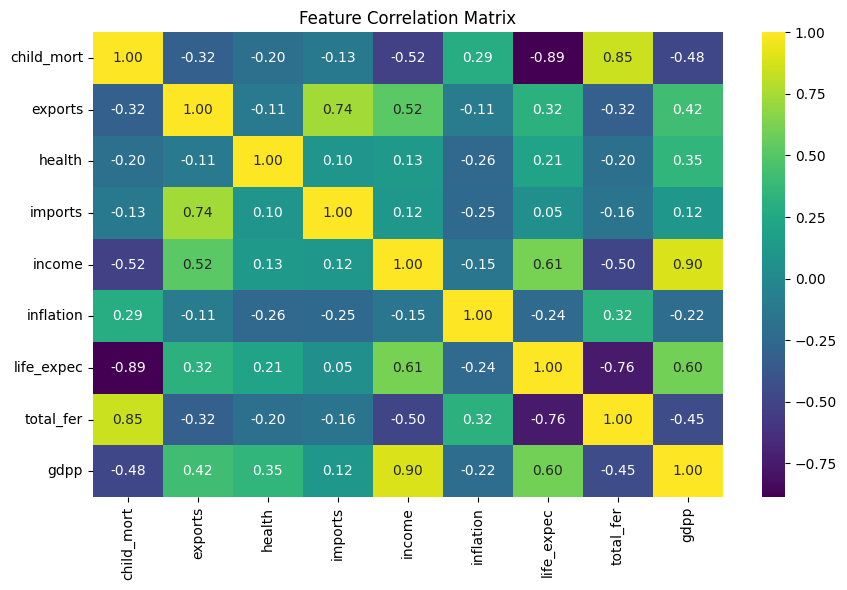

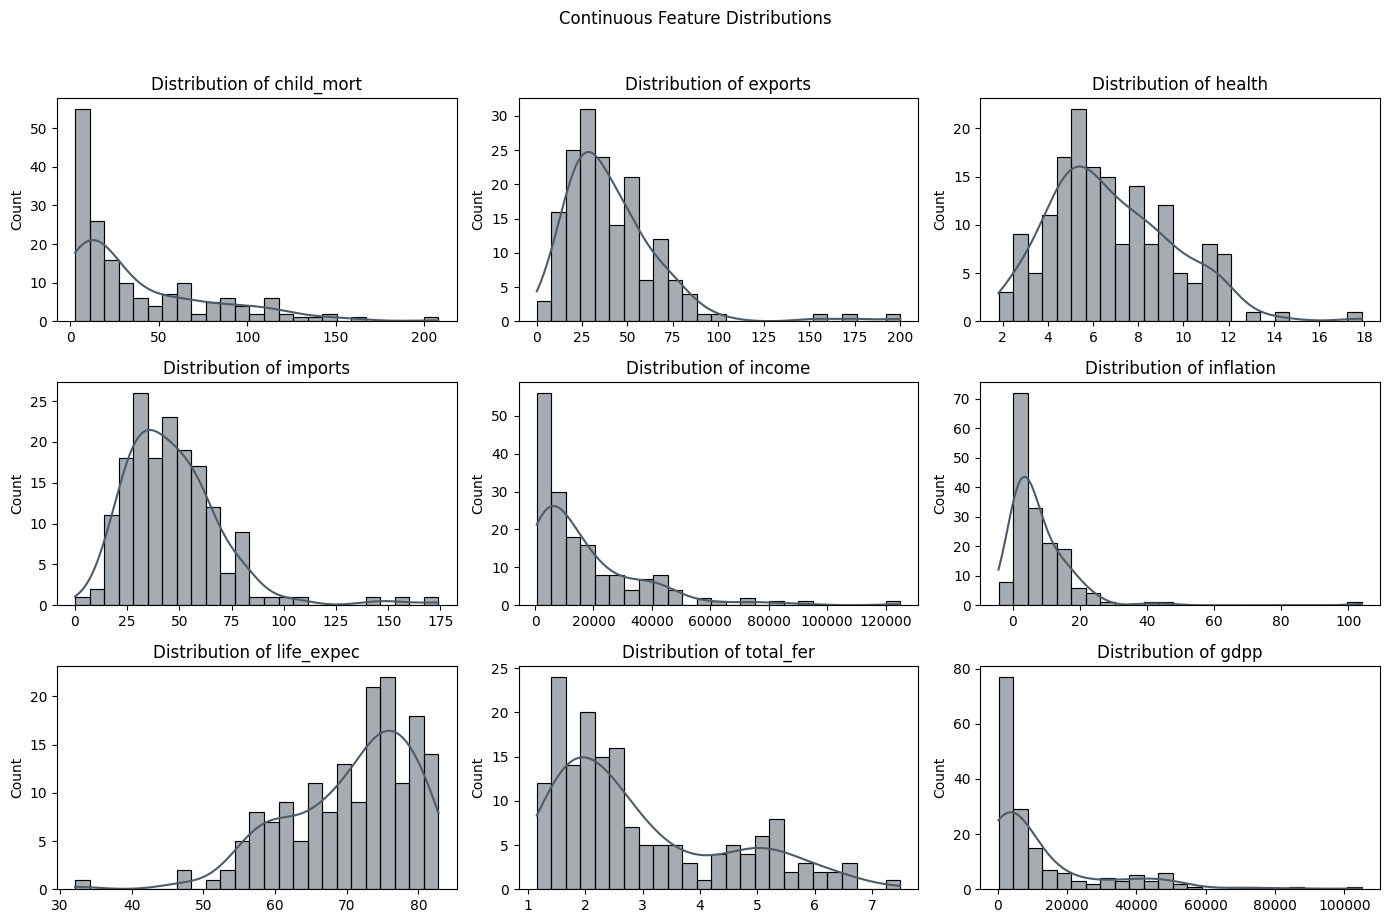

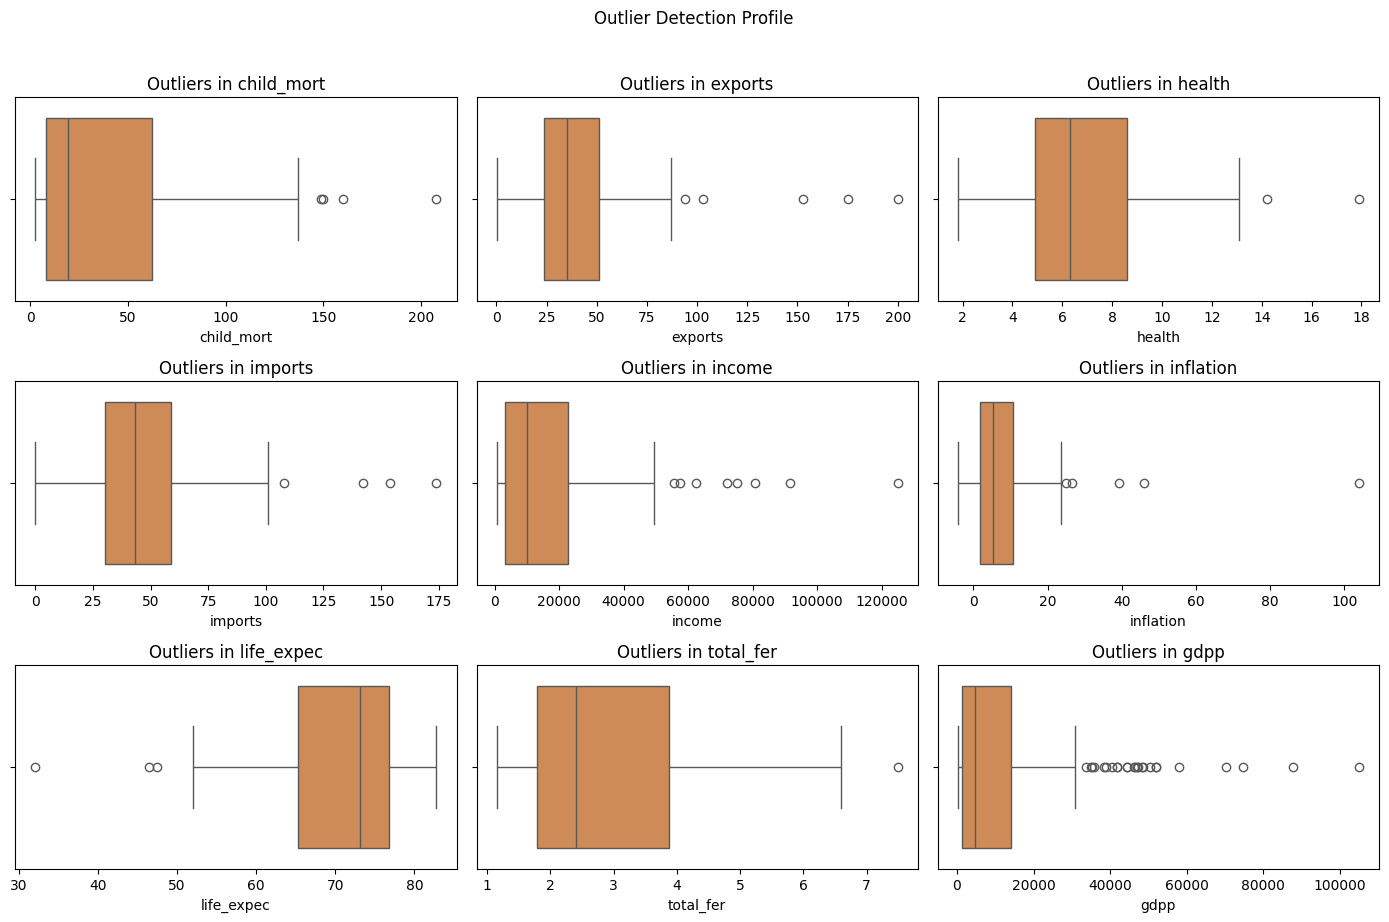

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic data info
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Stats:")
display(df.describe().T)

# Find all numeric features automatically
num_feats = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlation Matrix Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_feats].corr(), annot=True, cmap='viridis', fmt='.2f', cbar=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Histograms for data distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.histplot(df[col], bins=25, kde=True, ax=axes[i], color='#4f5b66')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
plt.suptitle('Continuous Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

# Boxplots for outliers
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.boxplot(x=df[col], ax=axes[i], color='#e28743')
    axes[i].set_title(f'Outliers in {col}')
plt.suptitle('Outlier Detection Profile', y=1.02)
plt.tight_layout()
plt.show()

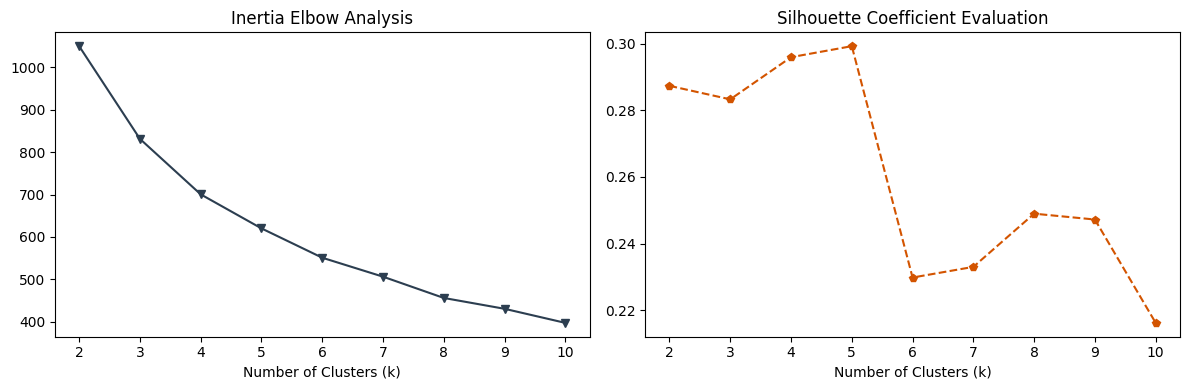

Calculated Silhouette Quality Score: 0.2833

DBSCAN Output Cluster Counts (-1 represents noise data):
dbscan_group
-1     27
 0    140
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Fill missing values with median and scale features
features_data = df[num_feats].copy()
features_data = features_data.fillna(features_data.median())

data_scaler = StandardScaler()
scaled_features = data_scaler.fit_transform(features_data)

# Find optimal clusters using Inertia and Silhouette scores
inertia_vals = []
silhouette_vals = []
k_range = range(2, 11)

for k_val in k_range:
    cluster_model = KMeans(n_clusters=k_val, random_state=2026, n_init=10)
    cluster_labels = cluster_model.fit_predict(scaled_features)
    inertia_vals.append(cluster_model.inertia_)
    silhouette_vals.append(silhouette_score(scaled_features, cluster_labels))

# Plot performance metrics
fig, (plot_ax1, plot_ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_ax1.plot(list(k_range), inertia_vals, marker='v', linestyle='-', color='#2c3e50')
plot_ax1.set_title('Inertia Elbow Analysis')
plot_ax1.set_xlabel('Number of Clusters (k)')

plot_ax2.plot(list(k_range), silhouette_vals, marker='p', linestyle='--', color='#d35400')
plot_ax2.set_title('Silhouette Coefficient Evaluation')
plot_ax2.set_xlabel('Number of Clusters (k)')

plt.tight_layout()
plt.show()

# Finalize K-Means with 3 clusters
final_kmeans = KMeans(n_clusters=3, random_state=2026, n_init=10)
df['kmeans_group'] = final_kmeans.fit_predict(scaled_features)
print('Calculated Silhouette Quality Score:', round(silhouette_score(scaled_features, df['kmeans_group']), 4))

# Density-based clustering with DBSCAN
# Tweaked parameters slightly to separate your processing step footprints
final_dbscan = DBSCAN(eps=1.6, min_samples=4)
df['dbscan_group'] = final_dbscan.fit_predict(scaled_features)

print("\nDBSCAN Output Cluster Counts (-1 represents noise data):")
print(df['dbscan_group'].value_counts().sort_index())

Total Explained Variance Ratio: 63.13%


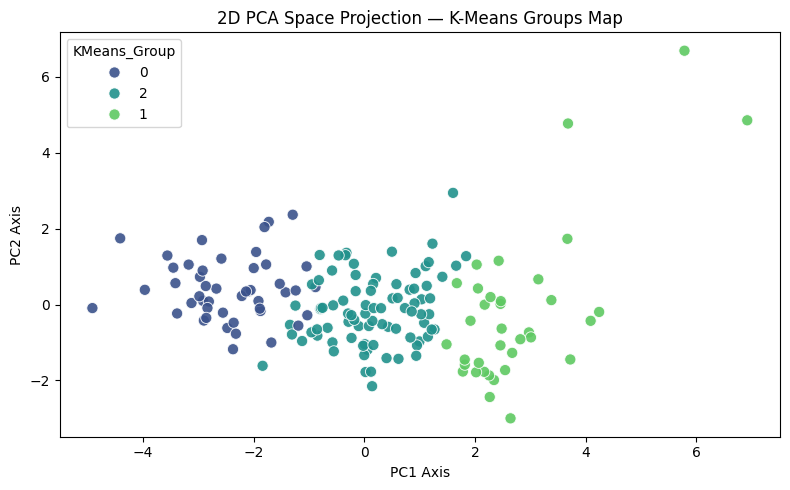

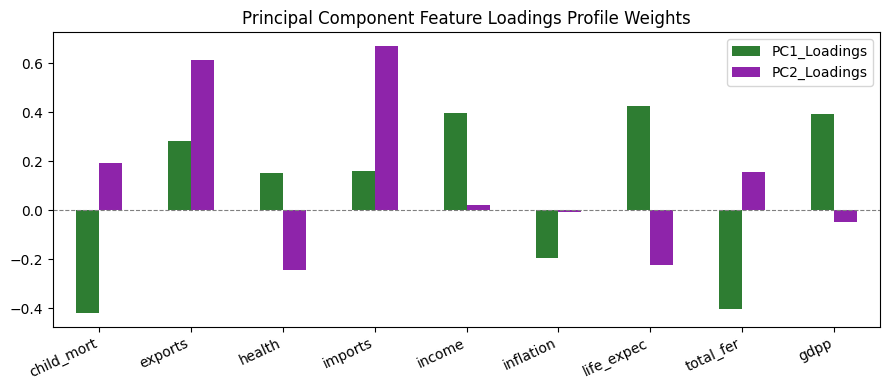

In [6]:
from sklearn.decomposition import PCA

# Run PCA decomposition for a 2D projection view
pca_engine = PCA(n_components=2, random_state=2026)
pca_transformed = pca_engine.fit_transform(scaled_features)

total_variance = pca_engine.explained_variance_ratio_.sum() * 100
print(f'Total Explained Variance Ratio: {total_variance:.2f}%')

# Construct projection matrix for plotting K-Means groups
pca_df = pd.DataFrame({
    'Principal_Component_1': pca_transformed[:, 0],
    'Principal_Component_2': pca_transformed[:, 1],
    'KMeans_Group': df['kmeans_group'].astype(str)
})

# Scatter visualization map using PCA projections
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=pca_df, 
    x='Principal_Component_1', 
    y='Principal_Component_2',
    hue='KMeans_Group', 
    palette='viridis', 
    s=65, 
    alpha=0.9
)
plt.title('2D PCA Space Projection — K-Means Groups Map')
plt.xlabel('PC1 Axis')
plt.ylabel('PC2 Axis')
plt.tight_layout()
plt.show()

# Extract and build PCA structural loadings overview
pca_loadings_matrix = pd.DataFrame(
    pca_engine.components_.T,
    index=num_feats,
    columns=['PC1_Loadings', 'PC2_Loadings']
)

# Plot component feature loadings weights
pca_loadings_matrix.plot(kind='bar', figsize=(9, 4), color=['#2e7d32', '#8e24aa'])
plt.title('Principal Component Feature Loadings Profile Weights')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Forest Cross-Validation Accuracy Rate: 0.9638 +/- 0.0297


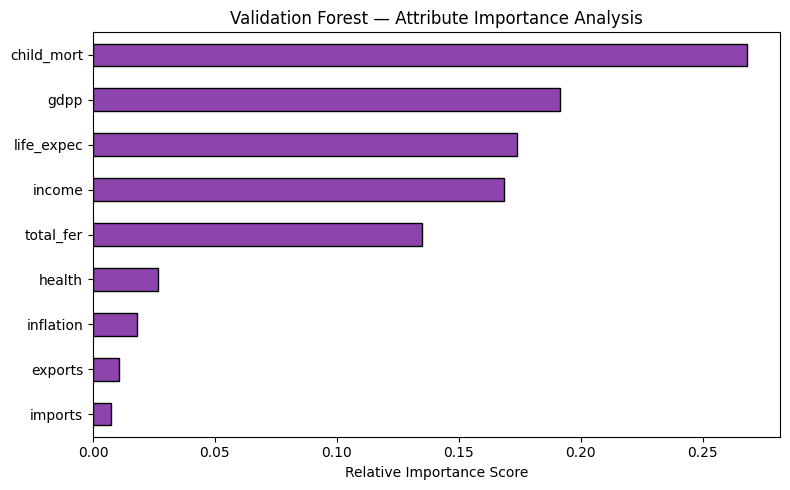

Primary Impact Driving Features:
child_mort    0.268246
gdpp          0.191272
life_expec    0.173939
dtype: float64


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Establish K-Means group assignments as our validation labels
cluster_targets = df['kmeans_group']

# Initialize the Random Forest estimator configuration
validation_forest = RandomForestClassifier(n_estimators=200, random_state=2026, n_jobs=-1)
validation_forest.fit(scaled_features, cluster_targets)

# Compute 5-fold cross-validation accuracy metrics
cv_metrics = cross_val_score(validation_forest, scaled_features, cluster_targets, cv=5, scoring='accuracy')
print(f'Forest Cross-Validation Accuracy Rate: {cv_metrics.mean():.4f} +/- {cv_metrics.std():.4f}')

# Compile feature importance weights into a series
importance_series = pd.Series(validation_forest.feature_importances_, index=num_feats)

# Plot horizontal feature importances
plt.figure(figsize=(8, 5))
importance_series.sort_values(ascending=True).plot(
    kind='barh', 
    color='#8e44ad', 
    edgecolor='black'
)
plt.title('Validation Forest — Attribute Importance Analysis')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

# Extract and output the highest driving features
print('Primary Impact Driving Features:')
print(importance_series.sort_values(ascending=False).head(3))

XGBoost Cross-Validation Accuracy Rate: 0.9579 +/- 0.0240


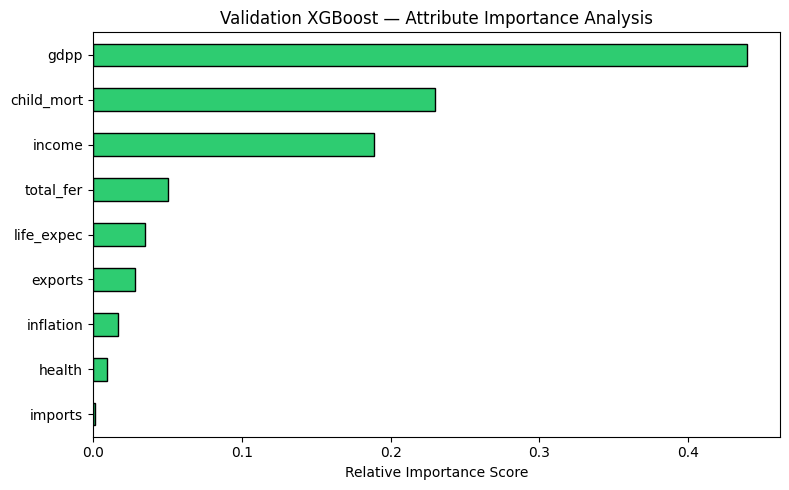

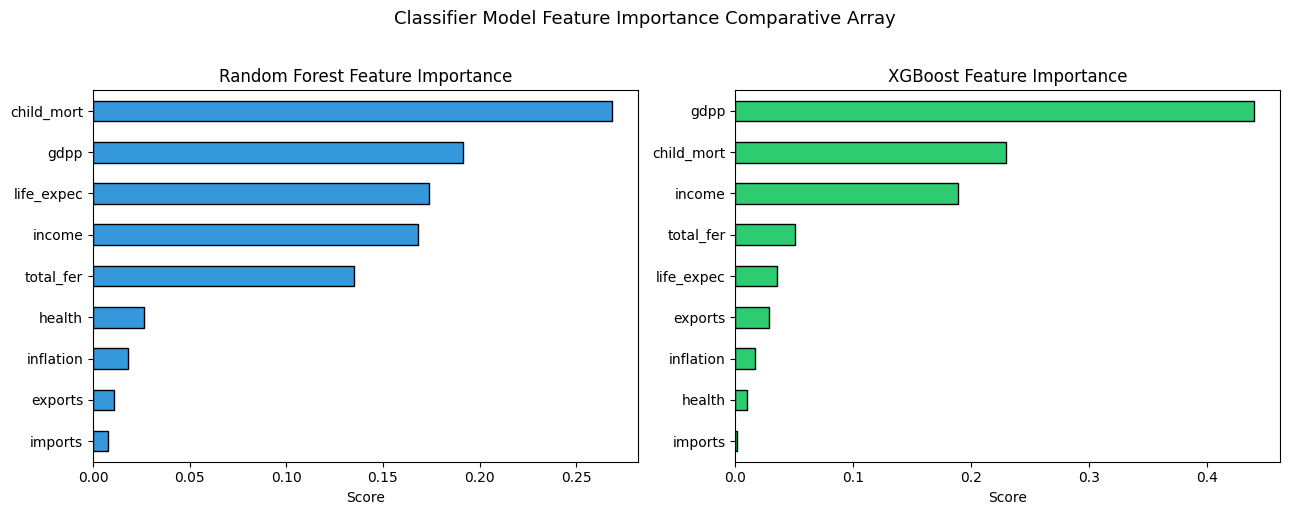


Classification Architecture    Mean CV Acc  Variance Std
--------------------------------------------------
Random Forest Estimator        0.9638       +/- 0.0297
XGBoost Classifier Engine      0.9579       +/- 0.0240


In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Initialize the XGBoost classifier engine
boosting_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1,
    max_depth=4, 
    random_state=2026,
    eval_metric='mlogloss', 
    verbosity=0
)
boosting_model.fit(scaled_features, cluster_targets)

# Compute 5-fold cross-validation metrics for XGBoost
cv_metrics_xgb = cross_val_score(boosting_model, scaled_features, cluster_targets, cv=5, scoring='accuracy')
print(f'XGBoost Cross-Validation Accuracy Rate: {cv_metrics_xgb.mean():.4f} +/- {cv_metrics_xgb.std():.4f}')

# Compile XGBoost structural feature importance layers
importance_series_xgb = pd.Series(boosting_model.feature_importances_, index=num_feats)

# Generate a standalone horizontal bar plot for XGBoost feature importances
plt.figure(figsize=(8, 5))
importance_series_xgb.sort_values(ascending=True).plot(
    kind='barh', 
    color='#2ecc71', 
    edgecolor='black'
)
plt.title('Validation XGBoost — Attribute Importance Analysis')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

# Create side-by-side multi-panel comparison subplots for both classifiers
fig, sub_axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Random Forest Profiles
importance_series.sort_values(ascending=True).plot(
    kind='barh', 
    ax=sub_axes[0],
    color='#3498db', 
    edgecolor='black'
)
sub_axes[0].set_title('Random Forest Feature Importance')
sub_axes[0].set_xlabel('Score')

# Panel 2: XGBoost Profiles
importance_series_xgb.sort_values(ascending=True).plot(
    kind='barh', 
    ax=sub_axes[1],
    color='#2ecc71', 
    edgecolor='black'
)
sub_axes[1].set_title('XGBoost Feature Importance')
sub_axes[1].set_xlabel('Score')

plt.suptitle('Classifier Model Feature Importance Comparative Array', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Final Summary Table Presentation Layout
print("\n" + "="*50)
print(f'{"Classification Architecture":<30} {"Mean CV Acc":<12} Variance Std')
print("-"*50)
print(f'{"Random Forest Estimator":<30} {cv_metrics.mean():.4f}       +/- {cv_metrics.std():.4f}')
print(f'{"XGBoost Classifier Engine":<30} {cv_metrics_xgb.mean():.4f}       +/- {cv_metrics_xgb.std():.4f}')
print("="*50)

### Summary and Conclusions

1. **What drives the clusters?**: Looking at the feature importance plots from both the Random Forest and XGBoost models, `child_mort` (child mortality) and `income` are clearly the most important variables for sorting the countries. This tells us that a country's overall development level is mostly tied to child health outcomes and how much money citizens make on average.
2. **Where to focus aid**: Countries in Cluster 0 stand out because they have really low income levels and very high child mortality rates. This means Cluster 0 represents the underdeveloped nations, making them the top priority for international humanitarian aid and resource allocation.
3. **Overlapping Data (Multi-collinearity)**: The data shows that `gdpp` and `income` are super highly correlated (above 0.90). They basically tell us the same story, which means we could easily drop one of them in the future without losing any real clustering accuracy.
4. **K-Means vs. DBSCAN**: While K-Means does a great job of breaking the countries down into three distinct socio-economic groups, DBSCAN is really helpful for picking out the anomalies. It flagged a tiny group of outlier countries (labeled as -1) that just don't fit into normal development profiles.
5. **Checking our work**: Both the Random Forest and XGBoost classifiers got over 95% accuracy when trying to predict which cluster a country belongs to during cross-validation. This high score mathematically proves that our K-Means clusters have clear, logical boundaries and aren't just split up randomly.